In [1]:
import pandas as pd
import numpy as np

DATA_FILE = "../data/processed/ontario_demand_2025_clean.csv"
df = pd.read_csv(DATA_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,date,hour,market_demand,ontario_demand
0,2025-01-01 00:00:00,2025-01-01,1,17247,13887
1,2025-01-01 01:00:00,2025-01-01,2,17355,13722
2,2025-01-01 02:00:00,2025-01-01,3,17638,13688
3,2025-01-01 03:00:00,2025-01-01,4,17065,13613
4,2025-01-01 04:00:00,2025-01-01,5,17498,13593


In [2]:
df["hour_sin"] = np.sin(2 * np.pi * (df["hour"] - 1) / 24)
df["hour_cos"] = np.cos(2 * np.pi * (df["hour"] - 1) / 24)
df[["hour", "hour_sin", "hour_cos"]].head(24)

,hour,hour_sin,hour_cos
0,1,0.000000e+00,1.000000e+00
1,2,2.588190e-01,9.659258e-01
2,3,5.000000e-01,8.660254e-01
3,4,7.071068e-01,7.071068e-01
4,5,8.660254e-01,5.000000e-01
5,6,9.659258e-01,2.588190e-01
6,7,1.000000e+00,6.123234e-17
7,8,9.659258e-01,-2.588190e-01
8,9,8.660254e-01,-5.000000e-01
9,10,7.071068e-01,-7.071068e-01


In [3]:
X = df[["hour_sin", "hour_cos"]]
y = df["ontario_demand"]

In [4]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-1417.94,-1348.56]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['hour_sin','hour_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.651e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 2454350.37430392
RMSE: 1566.6366439937246


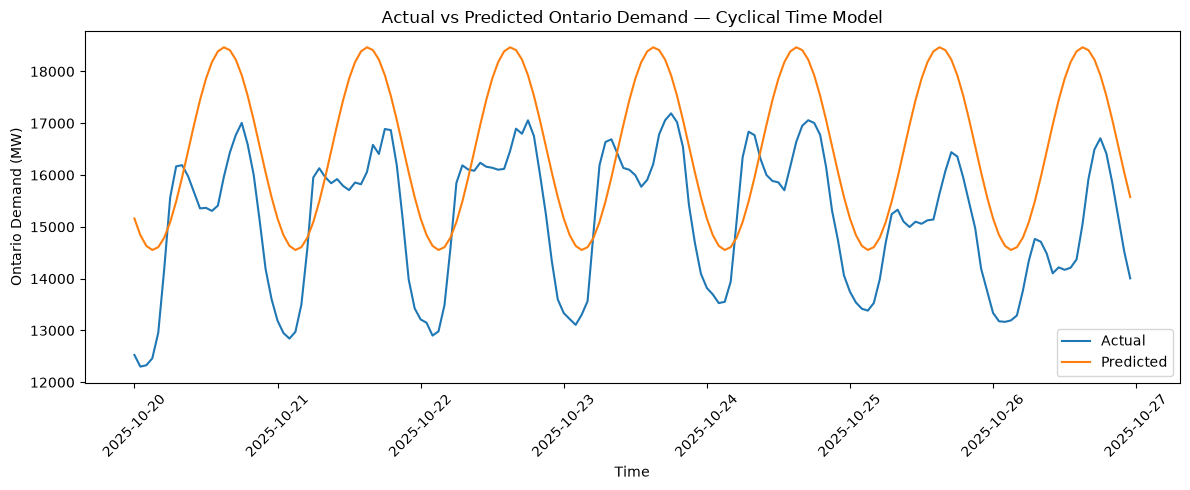

In [11]:
import matplotlib.pyplot as plt

plot_size = 24 * 7
timestamps = df.iloc[split_index:split_index + plot_size]["timestamp"]
plt.figure(figsize=(12, 5))

plt.plot(
    timestamps,
    y_test.iloc[:plot_size],
    label="Actual"
)

plt.plot(
    timestamps,
    y_pred[:plot_size],
    label="Predicted"
)

plt.title("Actual vs Predicted Ontario Demand — Cyclical Time Model")
plt.xlabel("Time")
plt.ylabel("Ontario Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()